In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from tqdm.auto import tqdm
from joblib import Parallel, delayed

from utils.collection.collect import make_info_df, get_seizure_lookup
from utils.collection.tensors import import_npz
from utils.exploration.processed_data import plot_window
from utils.preprocessing.features import compute_window_features, get_feature_names
from utils.preprocessing.labels import compute_window_labels

cur_dir = Path(os.getcwd())
proj_dir = cur_dir.resolve().parent.parent
RAW_DATA_PATH = proj_dir / "data" / "raw" 
RAW_RECORDS_PATH = RAW_DATA_PATH / "records"
INFO_PATH = RAW_DATA_PATH / "info"
PREPROC_DATA_PATH = proj_dir / "data" / "preprocessed"

# define the new path for feature vectors and labels vectors
FEATURE_DATA_PATH = proj_dir / "data" / "features"
FEATURE_DATA_PATH.mkdir(parents=True, exist_ok=True)
LABEL_DATA_PATH = proj_dir / "data" / "labels"
LABEL_DATA_PATH.mkdir(parents=True, exist_ok=True)

# Number of CPU cores to use (-1 uses all available)
N_CORES = -1 

SFREQ = 256
WINDOW_SEC = 5
OVERLAP = 0.5

SELECTED_SUBJECTS = [4,12,13,19]
SELECTED_NAMES = [f"chb{str(pid).zfill(2)}" for pid in SELECTED_SUBJECTS]
SELECTED_NAMES

['chb04', 'chb12', 'chb13', 'chb19']

# Feature Extraction and Labelling
Feature extraction and labeling are critical steps to transform high-dimensional raw EEG signals into a structured format that machine learning models can effectively interpret. This process simplifies the data while preserving essential temporal and spectral characteristics required for accurate seizure detection and forecasting.

## Import data and First Visualizations

In [2]:
data_info = make_info_df(info_dir=INFO_PATH)
data_info = data_info[data_info['subject'].isin(SELECTED_NAMES)].copy()
data_info

,subject,sampling_freq,num_seizures,seizure_durations,avg_seizure_dur,min_seizure_dur,max_seizure_dur,num_files,sex,age
3,chb04,256,4,"[49.0, 111.0, 102.0, 116.0]",94.500000,49.0,116.0,42,M,22
11,chb12,256,23,"[61.0, 32.0, 13.0, 23.0, 20.0, 26.0, -2457.0, ...",220.173913,-2647.0,2668.0,24,F,2
12,chb13,256,12,"[44.0, 70.0, 31.0, 64.0, 20.0, 18.0, 17.0, 62....",44.583333,17.0,70.0,33,F,3
18,chb19,256,3,"[78.0, 77.0, 81.0]",78.666667,77.0,81.0,30,F,19


Dataset loaded: (5758, 21, 1280) (windows, channels, samples)


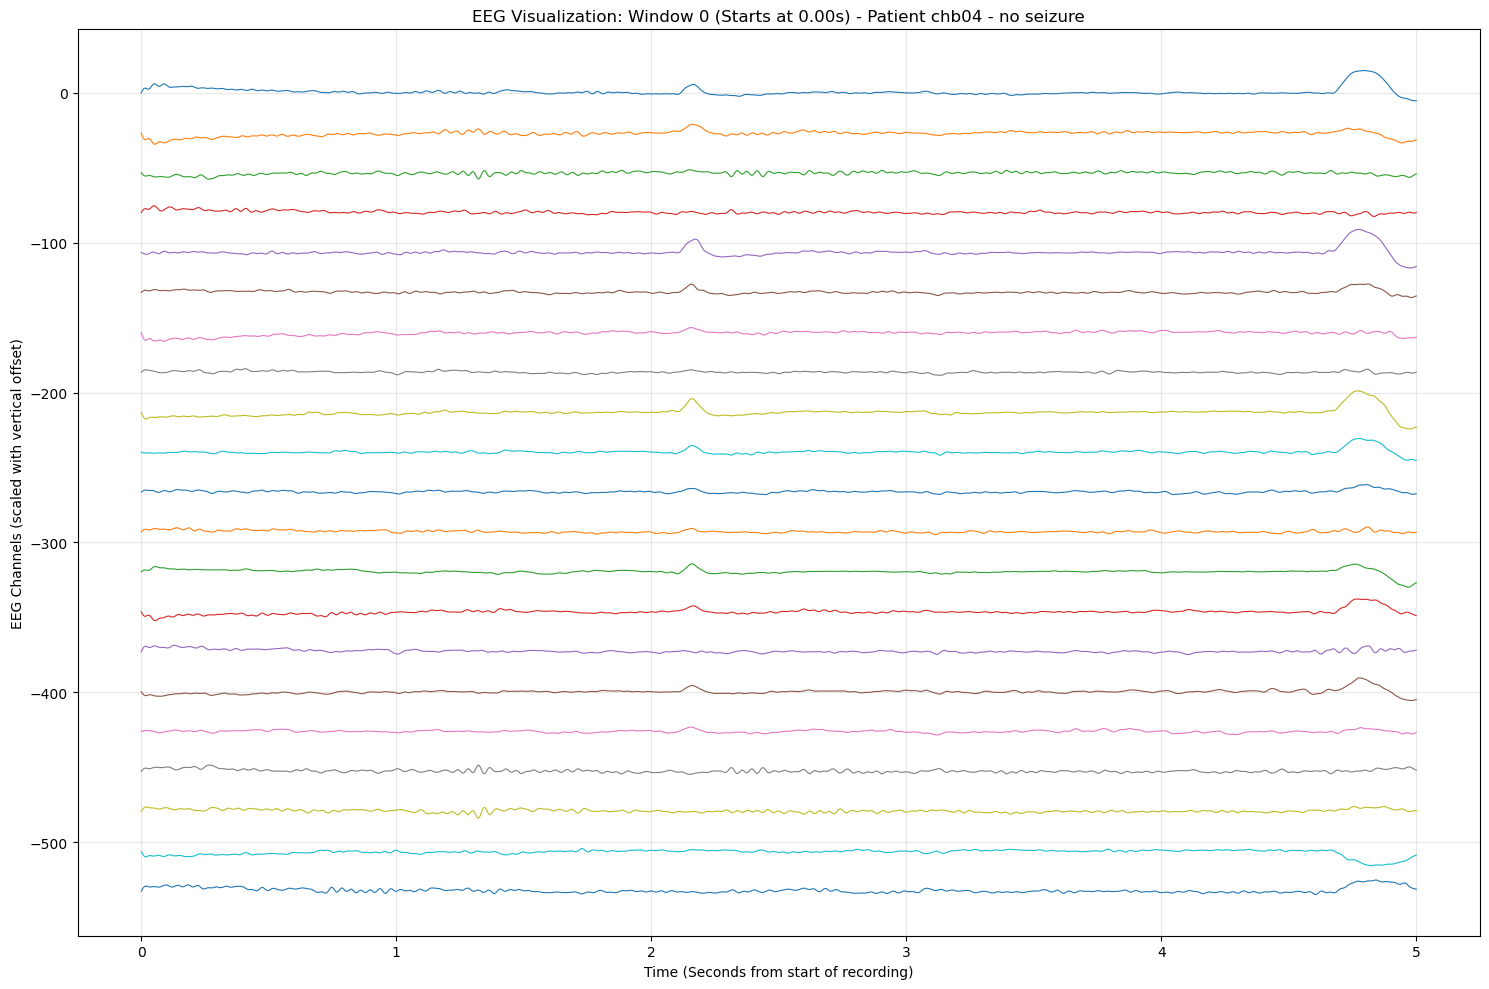

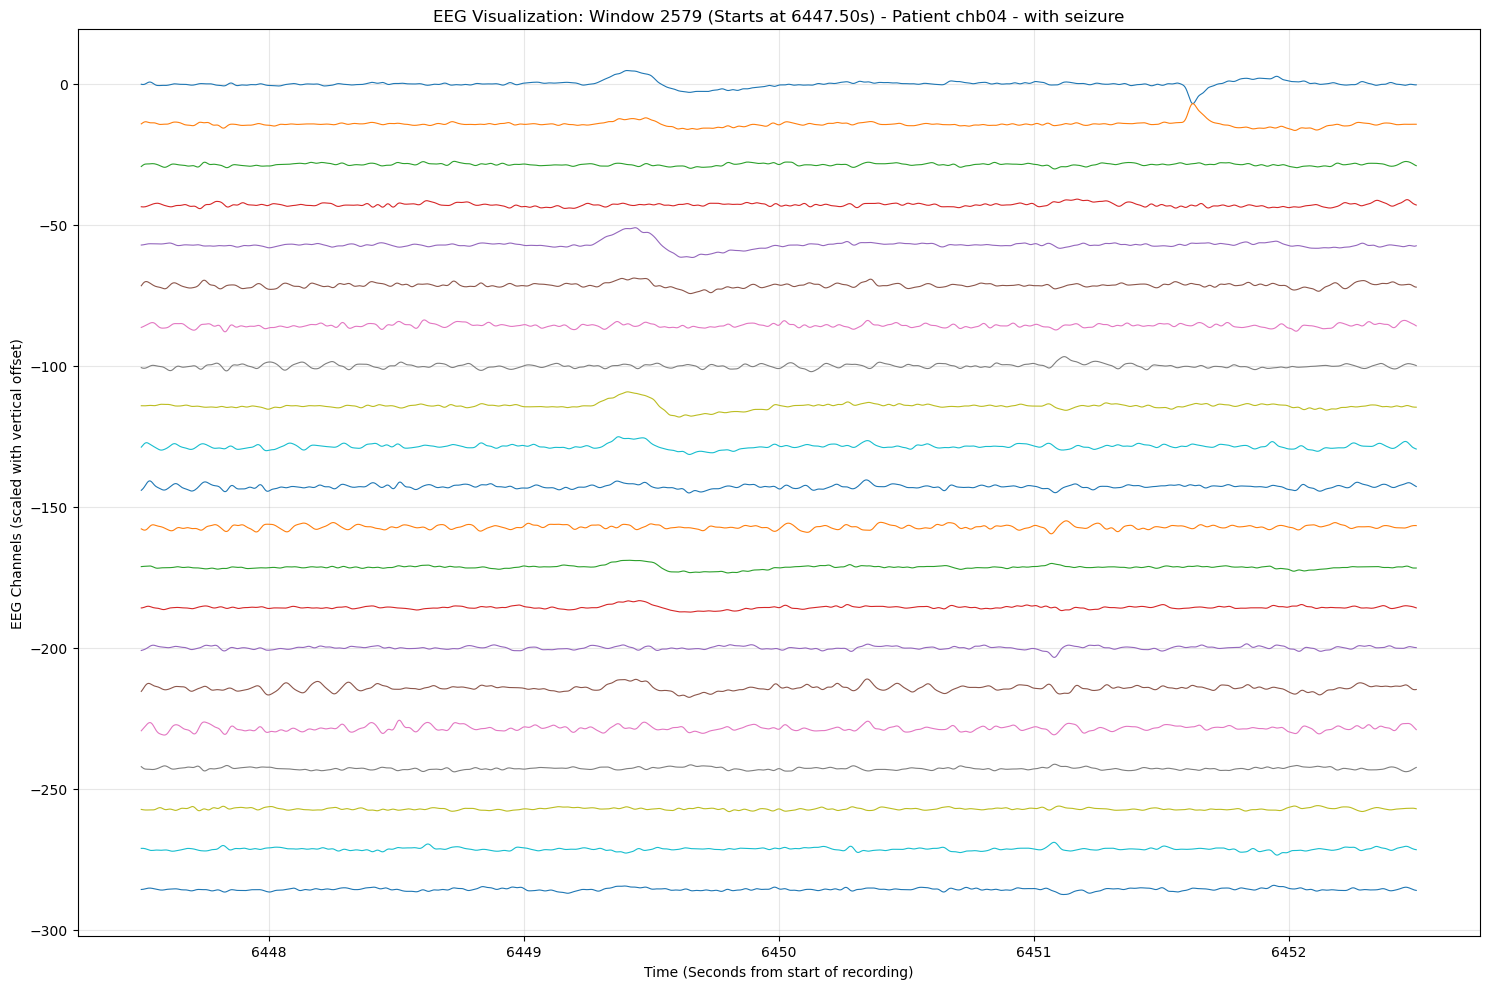

In [3]:
p_id, p_name = SELECTED_SUBJECTS[0], SELECTED_NAMES[0]
data = import_npz(p_id, 1, PREPROC_DATA_PATH)

# extract windows and channels and timestamps
windows = data['windows']
channels = data['channels']
times = data['times']

print(f"Dataset loaded: {windows.shape} (windows, channels, samples)")

# select a sezure from summary
SEIZURE_START = 6446
SEIZURE_END = 6557
# find indexes
ictal_indices = np.where((times >= SEIZURE_START) & (times <= SEIZURE_END))[0]
normal_indices = np.where(times < SEIZURE_START)[0]

# select window to viz without seizure
index_window = 0
if len(normal_indices) > 0:
    idx_norm = normal_indices[0]
    plot_window(idx_norm, windows, channels, times, offset=OVERLAP, sfreq=SFREQ, patient_name=f"{p_name} - no seizure")

# select window to viz with seizure
if len(ictal_indices) > 0:
    idx_seiz = ictal_indices[0]
    plot_window(idx_seiz, windows, channels, times, offset=OVERLAP, sfreq=SFREQ, patient_name=f"{p_name} - with seizure")
else:
    print("No windows found within the seizure timestamps. Check your windowing step/overlap.")

> The visual comparison between the non-seizure and seizure windows reveals a clear transition from relatively low-amplitude, stochastic background activity to more organized and rhythmic patterns. 

- **Normal Activity**: The background signals are "stochastic," meaning they appear more random, irregular, and lower in amplitude.

- **Seizure Activity**: The brain enters a state of "organized and rhythmic" firing. This creates sustained rhythmic oscillations and higher frequency synchronization across the channels, which is far more regular than the chaotic baseline.

## Add features
We decided to implement the following features:
- **Spectral Power Bands** (Delta, Theta, Alpha, Beta): track the energy at different speeds (frequencies). 
    > Seizures usually cause a massive shift in these speeds (for example, a sudden increase in Beta or Theta energy) which is a classic clinical marker.

- **Spectral Ratios** (STF, TAR, DAR, BAR): calculate the relationship between different frequency bands that act as an "amplifier" for clinical changes, highlighting the shift toward slow-wave activity that often precedes or accompanies a seizure while neutralizing background noise.
    - **STF -> Slow-To-Fast** ($\frac{(\theta + \delta)}{(\alpha + \beta)}$): This is arguably the most important ratio. During a seizure, the brain often moves from a state of fast, low-amplitude activity to high-amplitude, slow-rhythmic activity. This ratio amplifies that specific clinical shift.

    - **TAR -> Theta/Alpha Ratios**($\frac{\theta}{\alpha}$): Alpha waves are typical of a relaxed, wakeful state. An increase in Theta waves relative to Alpha is a classic sign of cognitive change or neurological instability.

    - **DAR -> Delta/Alpha Ratios** ($\frac{\delta}{\alpha}$): This is a standard clinical metric used to monitor brain distress. A high DAR is often associated with localized brain dysfunction or the start of an ictal event.
    
    - **BAR -> Beta/Alpha Ratios** ($\frac{\beta}{\alpha}$): Beta activity represents high-frequency excitation. Before some seizures, there is a period of "fast activity" (beta-bursts) that replaces the resting alpha rhythm.

- **Statistical Metrics** (Mean, Standard Deviation, Skewness, Kurtosis): used to describe the basic "size" and "shape" of the brain waves. 
    > They help to understand how much energy is in the signal and how much it varies from its average state.   

- **Hjorth Parameters** (Activity, Mobility, Complexity): represent the signal characteristics in the time domain through variance and its derivatives.
    > These parameters provide a compact description of the signal's mean frequency and "sinusoidal" purity, making them highly effective for identifying the onset of ictal rhythmic patterns.

- **Line Length**: measures the total "path" the signal travels in a window. 
    > It is one of the most effective ways to catch the sharp, "scratchy" spikes that appear during a seizure.


- **Zero-Crossing Rate** (ZCR): counts how many times the signal crosses the zero-axis within a window.
    > This is a low-cost computational indicator of the dominant frequency, signaling the rapid changes in rhythmicity typical of seizure transitions.

- **Petrosian Fractal Dimension**: fast calculation that measures how complex or "messy" the signal is. 
    > It helps distinguish between the random chaos of a normal brain and the more repetitive, rhythmic patterns of a seizure.

- **Pearson Correlation & Spectral Coherence**: looks at how well different parts of the brain are "talking" to each other. 
    > Used for forecasting because brain regions often start to synchronize or work in an abnormal "teamwork" pattern right before a seizure starts.

In [4]:
for p_name in tqdm(SELECTED_NAMES, desc="Subjects"):
    in_dir = PREPROC_DATA_PATH / p_name
    out_dir = FEATURE_DATA_PATH / p_name
    out_dir.mkdir(parents=True, exist_ok=True)

    npz_files = sorted(list(in_dir.glob("*.npz")))
    
    for f_path in tqdm(npz_files, desc=f"Files ({p_name})", leave=False):
        data = np.load(f_path)
        windows = data['windows']
        
        # Parallel execution across windows
        # delayed() to pass each window to the worker function
        matrix = Parallel(n_jobs=N_CORES)(
            delayed(compute_window_features)(windows[i], SFREQ) 
            for i in range(windows.shape[0])
        )

        # convert to array and save
        np.savez(out_dir / f_path.name, 
                 features=np.array(matrix), 
                 feature_names=get_feature_names(data['channels']), 
                 times=data['times'], 
                 channels=data['channels'])

        del windows, matrix, data
        gc.collect()

Subjects:   0%|          | 0/4 [00:00<?, ?it/s]

Files (chb04):   0%|          | 0/5 [00:00<?, ?it/s]

Files (chb12):   0%|          | 0/10 [00:00<?, ?it/s]

Files (chb13):   0%|          | 0/8 [00:00<?, ?it/s]

Files (chb19):   0%|          | 0/3 [00:00<?, ?it/s]

## Add Labels
We implemented two type of targets, one dedicated to the first task of *classification whether a window contains a seizure* and the second dedicated to the second task of *forecast when is the next seizure*.

- **Binary Classification** (`Is_Seizure`): every window is marked as 0 (Normal) or 1 (Seizure). This is necessary for Task 1 so the model can learn exactly what a crisis looks like compared to healthy brain activity.

- **Time-to-Seizure** (`TTS` - Time-To-Seizure): this is a countdown in seconds that tells the computer how much time is left before the next seizure begins. It is the core requirement for Task 2 (Forecasting), as it trains the model to predict a future event rather than just detecting a current one.

In [5]:
# compile seizures times registry
seizure_lookup = get_seizure_lookup(SELECTED_NAMES, INFO_PATH)
# like: seizure_lookup = { 'chb04_08': [(6446, 6557)], ... }

In [6]:
for p_name in tqdm(SELECTED_NAMES, desc="Subjects"):    
    # define paths
    in_dir = FEATURE_DATA_PATH / p_name # or PREPROC_DATA_PATH
    out_dir = LABEL_DATA_PATH / p_name
    out_dir.mkdir(parents=True, exist_ok=True)
    # find files
    npz_files = sorted(list(in_dir.glob("*.npz")))
    
    for f_path in tqdm(npz_files, desc=f"Labels ({p_name})", leave=False):
        # load file
        data = np.load(f_path)
        times = data['times']
        f_name = f_path.stem
        
        # get seizure intervals for specific file from metadata
        intervals = seizure_lookup.get(f_name, []) 
        
        # Parallel computation of labels
        labels = Parallel(n_jobs=-1)(
            delayed(compute_window_labels)(t, intervals, WINDOW_SEC) 
            for t in times
        )
        
        labels = np.array(labels)
        
        # save Task 01 (col 0) and Task 02 (col 1)
        np.savez(out_dir / f_path.name, 
                 y_task1=labels[:, 0], # classification (0/1)
                 y_task2=labels[:, 1], # forecast (Time-To-Seizure)
                 times=times)

        del data, labels
        gc.collect()

print("\nLabel generation complete.")

Subjects:   0%|          | 0/4 [00:00<?, ?it/s]

Labels (chb04):   0%|          | 0/5 [00:00<?, ?it/s]

Labels (chb12):   0%|          | 0/10 [00:00<?, ?it/s]

Labels (chb13):   0%|          | 0/8 [00:00<?, ?it/s]

Labels (chb19):   0%|          | 0/3 [00:00<?, ?it/s]


Label generation complete.


## Check the correct creation
This verification process aligns extracted feature values with seizure timestamps to confirm that physiological markers significantly deviate from the baseline during ictal events.

In [11]:
# choose a file known to have a seizure (e.g., chb04_08)
p_id, f_name = "chb04", "chb04_08"
feat_path = FEATURE_DATA_PATH / p_id / f"{f_name}.npz"
label_path = LABEL_DATA_PATH / p_id / f"{f_name}.npz"

# load data
feat_data = np.load(feat_path)
lab_data = np.load(label_path)

# extract arrays
X = feat_data['features']
names = feat_data['feature_names']
times = feat_data['times']
y_task1 = lab_data['y_task1']
y_task2 = lab_data['y_task2']

# create a small summary for seizure windows
df_verify = pd.DataFrame({
    'Time (s)': times,
    'Is_Seizure': y_task1,
    'TTS (s)': y_task2
})

# add some features
for i in range(10):
    feat = X[:, i]
    feat_name = names[i]
    df_verify[feat_name] = feat

print(f"--- Verification for {f_name} ---")
print(f"Feature Matrix Shape: {X.shape} (Windows x Features)")
print(f"Number of Feature Names: {len(names)}")

# sample where a seizure starts (around 6446s for chb04_08)
seizure_start_idx = np.where(y_task1 == 1)[0]
if len(seizure_start_idx) > 0:
    first_idx = seizure_start_idx[0]
    # show 5 windows before and 5 windows during seizure
    display(df_verify.iloc[max(0, first_idx-5) : first_idx+5])
else:
    print("No seizure found in this specific file.")

--- Verification for chb04_08 ---
Feature Matrix Shape: (5758, 627) (Windows x Features)
Number of Feature Names: 627


,Time (s),Is_Seizure,TTS (s),FP1-F7_delta_pwr,F7-T7_delta_pwr,T7-P7_delta_pwr,P7-O1_delta_pwr,FP1-F3_delta_pwr,F3-C3_delta_pwr,C3-P3_delta_pwr,P3-O1_delta_pwr,FP2-F4_delta_pwr,F4-C4_delta_pwr
2572,6430.0,0.0,16.0,0.129985,0.432492,0.352385,0.120198,0.165451,0.134922,7.197398,4.932271,0.246527,0.124193
2573,6432.5,0.0,13.5,0.125210,0.431564,0.382646,0.149303,0.121163,0.156265,7.360045,5.003628,0.153707,0.172635
2574,6435.0,0.0,11.0,0.038263,0.052515,0.054932,0.050209,0.059110,0.049716,0.119131,0.098786,0.150834,0.105298
2575,6437.5,0.0,8.5,0.021978,0.028204,0.025535,0.022382,0.048713,0.043563,0.066939,0.050659,0.122886,0.059053
2576,6440.0,0.0,6.0,0.029396,0.020876,0.051693,0.022038,0.035760,0.035643,0.056134,0.047591,0.058683,0.051137
2577,6442.5,1.0,0.0,0.080405,0.041470,0.077351,0.029252,0.104246,0.099607,0.077102,0.089733,0.214188,0.120556
2578,6445.0,1.0,0.0,0.238510,0.110647,0.117119,0.080885,0.160641,0.212827,0.081662,0.105837,0.275632,0.358995
2579,6447.5,1.0,0.0,0.291590,0.212274,0.166535,0.222473,0.183148,0.244106,0.079629,0.097132,0.381355,0.513163
2580,6450.0,1.0,0.0,0.362104,0.256177,0.446870,0.311852,0.725845,0.370293,0.249322,0.200468,1.165966,0.665670
2581,6452.5,1.0,0.0,0.338529,0.157115,0.631357,0.312051,1.299193,0.468444,0.304343,0.300462,1.806507,0.757456


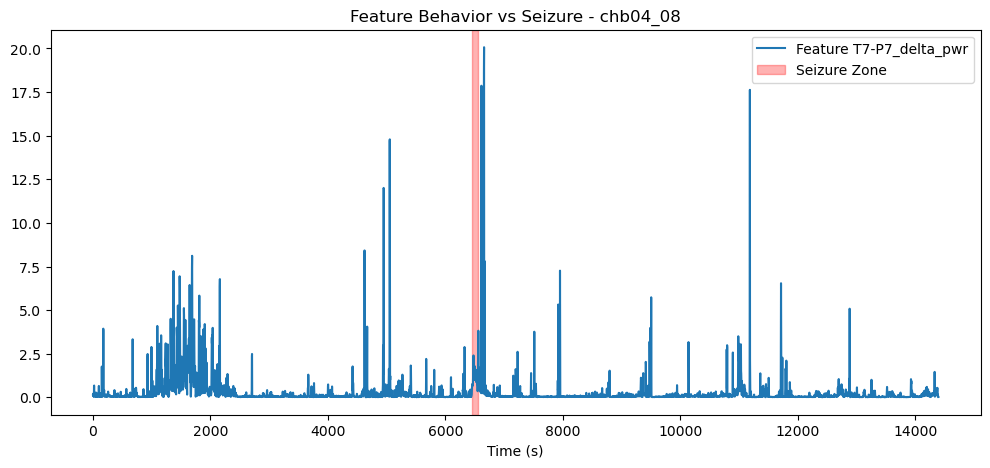

In [9]:
# Plot Line Length of the first channel vs Time
# Line length usually spikes during a seizure
feat_index = 2
intervals = seizure_lookup.get(f_name, [])

plt.figure(figsize=(12, 5))
plt.plot(times, X[:, feat_index], label=f"Feature {names[feat_index]}")
for i, (start, end) in enumerate(intervals):
    label = 'Seizure Zone' if i == 0 else "" # Avoid duplicate legend entries
    plt.axvspan(start, end, color='red', alpha=0.3, label=label)
plt.title(f"Feature Behavior vs Seizure - {f_name}")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

In [10]:
seizure_mask = (y_task1 == 1)
if seizure_mask.any():
    avg_during = np.mean(X[seizure_mask, feat_index])
    avg_before = np.mean(X[~seizure_mask, feat_index])
    print(f"--- Statistics for {names[feat_index]} ---")
    print(f"Average during Seizure: {avg_during:.4f}")
    print(f"Average during Normal:  {avg_before:.4f}")
    print(f"Ratio (Seizure/Normal): {avg_during/avg_before:.2f}x")

--- Statistics for T7-P7_delta_pwr ---
Average during Seizure: 1.0637
Average during Normal:  0.2847
Ratio (Seizure/Normal): 3.74x
